In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.decomposition import PCA, KernelPCA
from sklearn.feature_selection import RFE
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import MDS, TSNE
from sklearn.datasets import fetch_openml
from umap import UMAP

In [45]:
mnist = fetch_openml("mnist_784", version=1, parser="auto")
X_mnist = mnist.data.to_numpy()
y_mnist = mnist.target.to_numpy()

fashion_mnist = fetch_openml("Fashion-MNIST", version=1, parser="auto")
X_fashion = fashion_mnist.data.to_numpy()
y_fashion = fashion_mnist.target.to_numpy()

print(f"MNIST shape: {X_mnist.shape}, Labels: {y_mnist.shape}")
print(f"Fashion MNIST shape: {X_fashion.shape}, Labels: {y_fashion.shape}")

MNIST shape: (70000, 784), Labels: (70000,)
Fashion MNIST shape: (70000, 784), Labels: (70000,)


In [46]:
img_h, img_w = 28, 28
mnist_classes = [str(i) for i in range(10)]
fashion_classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

print("=" * 45)
print(f"{'Property':<25} {'MNIST':>8} {'F-MNIST':>10}")
print("=" * 45)
print(f"{'Samples':<25} {X_mnist.shape[0]:>8,} {X_fashion.shape[0]:>10,}")
print(f"{'Features (pixels)':<25} {X_mnist.shape[1]:>8} {X_fashion.shape[1]:>10}")
print(f"{'Image height':<25} {img_h:>8} {img_h:>10}")
print(f"{'Image width':<25} {img_w:>8} {img_w:>10}")
print(
    f"{'Unique classes':<25} {len(np.unique(y_mnist)):>8} {len(np.unique(y_fashion)):>10}"
)
print(f"{'Data type':<25} {str(X_mnist.dtype):>8} {str(X_fashion.dtype):>10}")
print("=" * 45)

Property                     MNIST    F-MNIST
Samples                     70,000     70,000
Features (pixels)              784        784
Image height                    28         28
Image width                     28         28
Unique classes                  10         10
Data type                    int64      int64


In [47]:
X_mnist = X_mnist / 255.0
X_fashion = X_fashion / 255.0

In [48]:
def arrange_tiles_img(examples: np.array) -> np.array:
    rows_count, cols_count, tile_height, tile_width = examples.shape

    space_between_tiles = 2
    img_matrix = np.empty(
        shape=(
            rows_count * (tile_height + space_between_tiles) - space_between_tiles,
            cols_count * (tile_width + space_between_tiles) - space_between_tiles,
        )
    )
    img_matrix.fill(np.nan)

    for y in range(rows_count):
        for x in range(cols_count):
            start_y = y * (tile_height + space_between_tiles)
            start_x = x * (tile_width + space_between_tiles)
            img_matrix[
                start_y : start_y + tile_height, start_x : start_x + tile_width
            ] = examples[y, x]

    return img_matrix

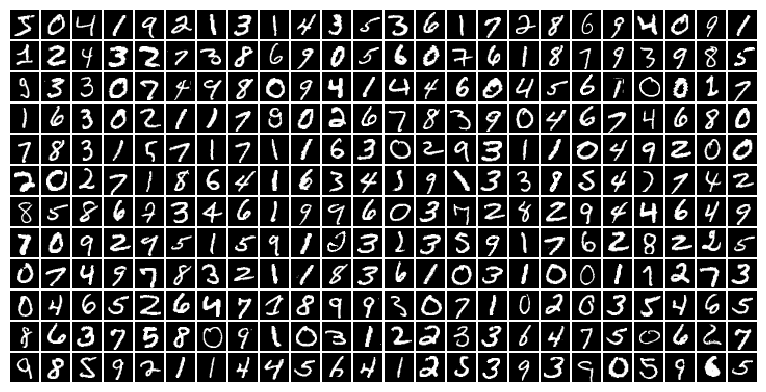

In [49]:
n_rows = 12
n_cols = 24
tile_dim = 28
shape = (n_rows, n_cols, tile_dim, tile_dim)
mnist_digits = np.reshape(X_mnist[: 12 * 24], newshape=shape)

tiles_img = arrange_tiles_img(mnist_digits)

plt.matshow(tiles_img, cmap="gray", interpolation="none")
plt.axis("off")
plt.show()

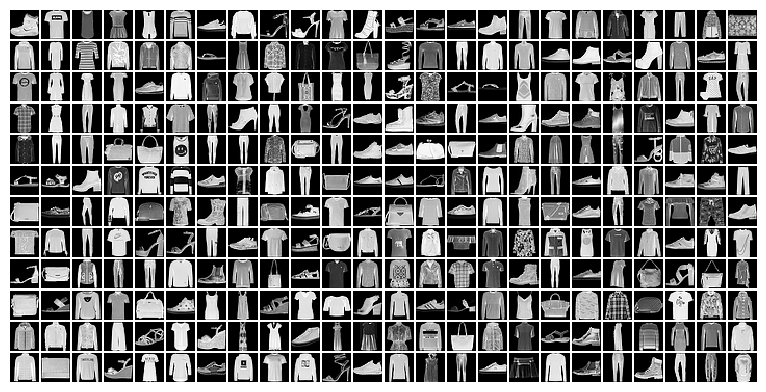

In [50]:
n_rows = 12
n_cols = 24
tile_dim = 28
shape = (n_rows, n_cols, tile_dim, tile_dim)
fmnist_digits = np.reshape(X_fashion[: 12 * 24], newshape=shape)

tiles_img = arrange_tiles_img(fmnist_digits)

plt.matshow(tiles_img, cmap="gray", interpolation="none")
plt.axis("off")
plt.show()

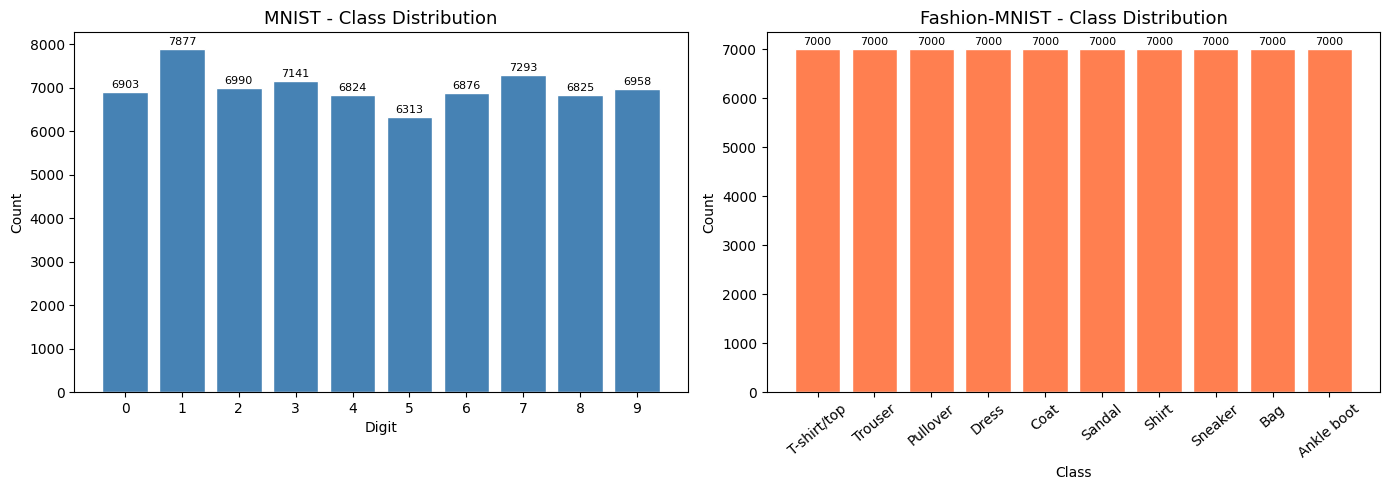

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_mnist_int = y_mnist.astype(int)
y_fashion_int = y_fashion.astype(int)

counts_mnist = np.bincount(y_mnist_int)
counts_fashion = np.bincount(y_fashion_int)

axes[0].bar(mnist_classes, counts_mnist, color="steelblue", edgecolor="white")
axes[0].set_title("MNIST - Class Distribution", fontsize=13)
axes[0].set_xlabel("Digit")
axes[0].set_ylabel("Count")
for i, c in enumerate(counts_mnist):
    axes[0].text(i, c + 50, str(c), ha="center", va="bottom", fontsize=8)

axes[1].bar(fashion_classes, counts_fashion, color="coral", edgecolor="white")
axes[1].set_title("Fashion-MNIST - Class Distribution", fontsize=13)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=40)
for i, c in enumerate(counts_fashion):
    axes[1].text(i, c + 50, str(c), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

---
## 2. Dimensionality Reduction

Methods applied: **t-SNE**, **UMAP**, **TriMAP**, **PaCMAP**

In [ ]:
import trimap
import pacmap

N = 1000
rng = np.random.default_rng(42)

idx_m = rng.choice(len(X_mnist), N, replace=False)
idx_f = rng.choice(len(X_fashion), N, replace=False)

Xm = X_mnist[idx_m].astype(np.float32)
ym = y_mnist[idx_m].astype(int)
Xf = X_fashion[idx_f].astype(np.float32)
yf = y_fashion[idx_f].astype(int)

Xm_pca = PCA(n_components=50, random_state=42).fit_transform(Xm)
Xf_pca = PCA(n_components=50, random_state=42).fit_transform(Xf)
print(f"Subset shape: {Xm.shape}  →  PCA: {Xm_pca.shape}")

PAL = np.array(sns.color_palette("tab10", 10))


def scatter_emb(ax, emb, labels, title):
    for c in range(10):
        mask = labels == c
        ax.scatter(emb[mask, 0], emb[mask, 1], s=1.5, alpha=0.55, color=PAL[c])
    ax.set_title(title, fontsize=8.5)
    ax.set_xticks([])
    ax.set_yticks([])


def add_legend(fig, names, ncol=5):
    patches = [mpl.patches.Patch(color=PAL[i], label=names[i]) for i in range(10)]
    fig.legend(
        handles=patches,
        loc="lower center",
        ncol=ncol,
        fontsize=7.5,
        bbox_to_anchor=(0.5, -0.01),
    )

Subset shape: (10000, 784)  →  PCA: (10000, 50)


### t-SNE - perplexity $\in$ {5, 30, 50}

t-SNE perplexity= 5  done
t-SNE perplexity=30  done
t-SNE perplexity=50  done


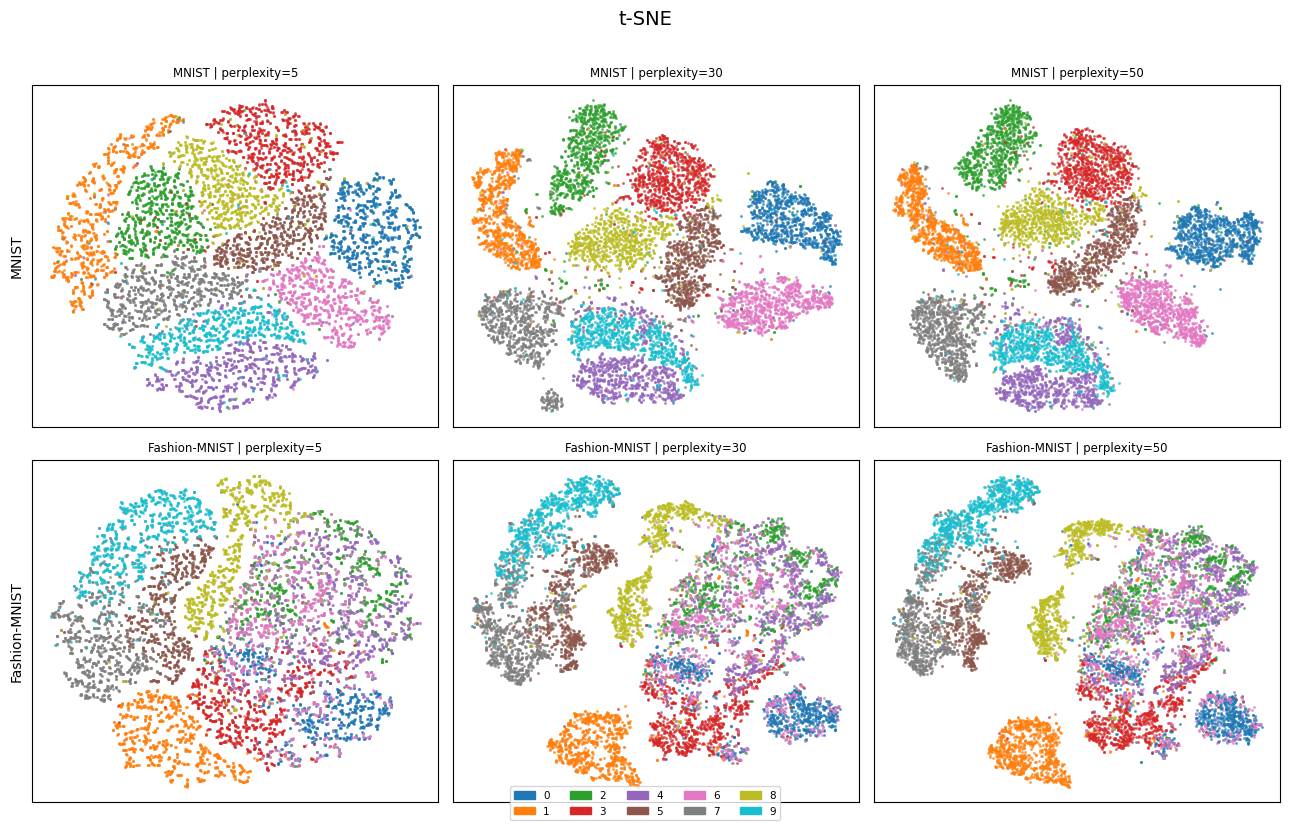

In [53]:
perplexities = [5, 30, 50]
tsne_emb = {}

for perp in perplexities:
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        early_exaggeration=12,
        max_iter=1000,
        init="pca",
        random_state=42,
    )
    tsne_emb[("mnist", perp)] = tsne.fit_transform(Xm_pca)
    tsne_emb[("fashion", perp)] = tsne.fit_transform(Xf_pca)
    print(f"t-SNE perplexity={perp:>2}  done")

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for j, perp in enumerate(perplexities):
    scatter_emb(axes[0, j], tsne_emb[("mnist", perp)], ym, f"MNIST | perplexity={perp}")
    scatter_emb(
        axes[1, j],
        tsne_emb[("fashion", perp)],
        yf,
        f"Fashion-MNIST | perplexity={perp}",
    )

axes[0, 0].set_ylabel("MNIST", fontsize=10, labelpad=6)
axes[1, 0].set_ylabel("Fashion-MNIST", fontsize=10, labelpad=6)
fig.suptitle("t-SNE", fontsize=14, y=1.01)
add_legend(fig, mnist_classes)
plt.tight_layout()
plt.show()

###  UMAP - n_neighbors $\in$ {5, 15, 30}, min_dist $\in$ {0.1, 0.5, 0.8}

C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP n_neighbors= 5, min_dist=0.1  done


C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP n_neighbors=15, min_dist=0.5  done


C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP n_neighbors=30, min_dist=0.8  done


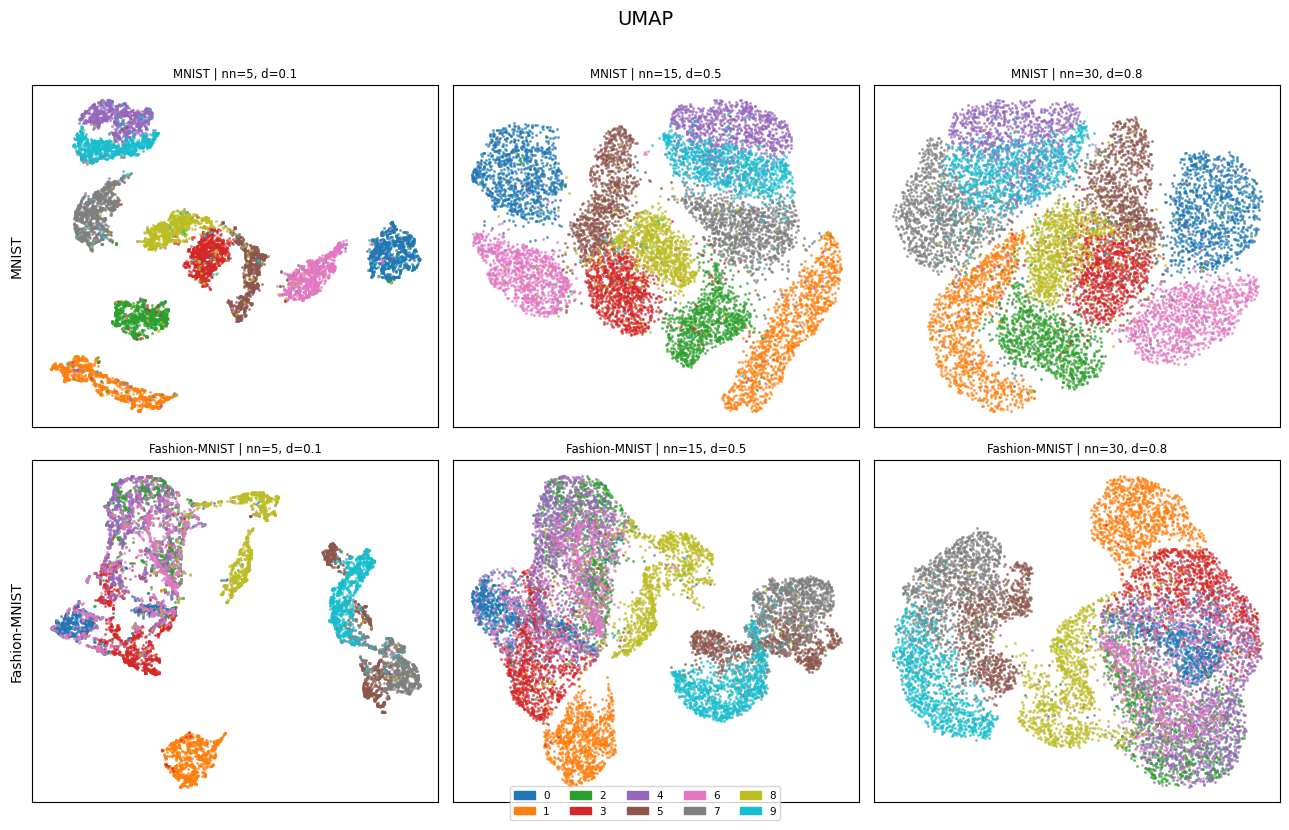

In [54]:
umap_configs = [
    {"n_neighbors": 5, "min_dist": 0.1},
    {"n_neighbors": 15, "min_dist": 0.5},
    {"n_neighbors": 30, "min_dist": 0.8},
]
umap_emb = {}

for cfg in umap_configs:
    key = (cfg["n_neighbors"], cfg["min_dist"])
    reducer = UMAP(n_components=2, **cfg)
    umap_emb[("mnist", *key)] = reducer.fit_transform(Xm_pca)
    umap_emb[("fashion", *key)] = reducer.fit_transform(Xf_pca)
    print(f"UMAP n_neighbors={cfg['n_neighbors']:>2}, min_dist={cfg['min_dist']}  done")

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for j, cfg in enumerate(umap_configs):
    key = (cfg["n_neighbors"], cfg["min_dist"])
    label = f"nn={key[0]}, d={key[1]}"
    scatter_emb(axes[0, j], umap_emb[("mnist", *key)], ym, f"MNIST | {label}")
    scatter_emb(axes[1, j], umap_emb[("fashion", *key)], yf, f"Fashion-MNIST | {label}")

axes[0, 0].set_ylabel("MNIST", fontsize=10, labelpad=6)
axes[1, 0].set_ylabel("Fashion-MNIST", fontsize=10, labelpad=6)
fig.suptitle("UMAP", fontsize=14, y=1.01)
add_legend(fig, mnist_classes)
plt.tight_layout()
plt.show()

### TriMAP - n_inliers $\in$ {10, 20}, n_outliers $\in$ {5, 10}

TriMAP n_inliers=10, n_outliers=5  done
TriMAP n_inliers=10, n_outliers=10  done
TriMAP n_inliers=20, n_outliers=5  done
TriMAP n_inliers=20, n_outliers=10  done


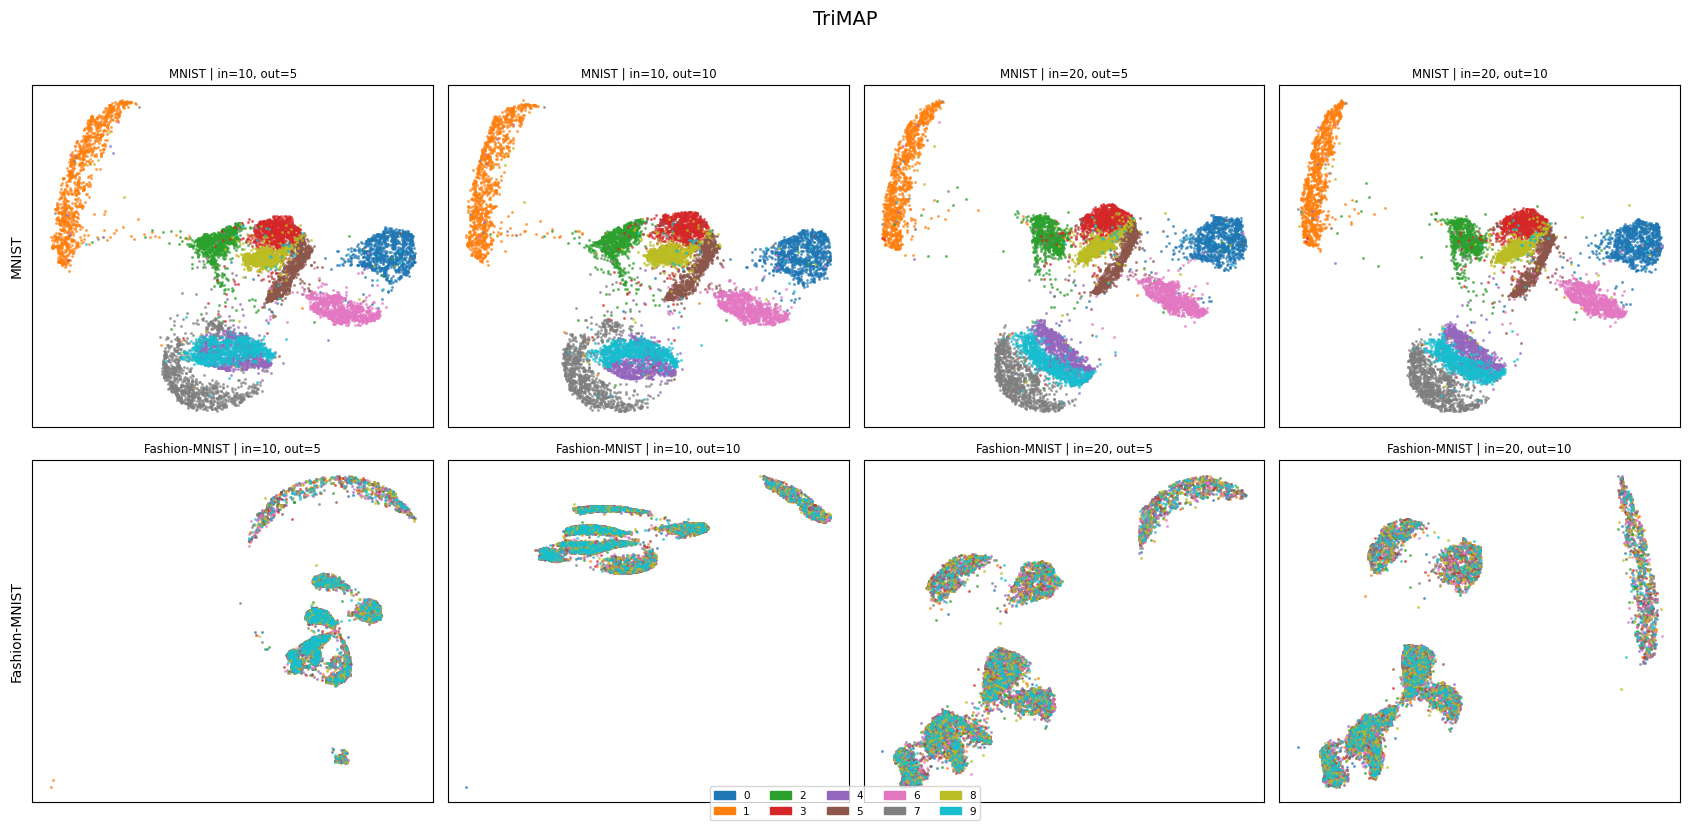

In [55]:
trimap_configs = [
    {"n_inliers": 10, "n_outliers": 5},
    {"n_inliers": 10, "n_outliers": 10},
    {"n_inliers": 20, "n_outliers": 5},
    {"n_inliers": 20, "n_outliers": 10},
]
trimap_emb = {}

for cfg in trimap_configs:
    key = (cfg["n_inliers"], cfg["n_outliers"])
    reducer = trimap.TRIMAP(n_inliers=cfg["n_inliers"], n_outliers=cfg["n_outliers"])
    trimap_emb[("mnist", *key)] = reducer.fit_transform(Xm_pca)
    trimap_emb[("fashion", *key)] = reducer.fit_transform(Xf_pca)
    print(f"TriMAP n_inliers={cfg['n_inliers']}, n_outliers={cfg['n_outliers']}  done")

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for j, cfg in enumerate(trimap_configs):
    key = (cfg["n_inliers"], cfg["n_outliers"])
    label = f"in={key[0]}, out={key[1]}"
    scatter_emb(axes[0, j], trimap_emb[("mnist", *key)], ym, f"MNIST | {label}")
    scatter_emb(
        axes[1, j], trimap_emb[("fashion", *key)], yf, f"Fashion-MNIST | {label}"
    )

axes[0, 0].set_ylabel("MNIST", fontsize=10, labelpad=6)
axes[1, 0].set_ylabel("Fashion-MNIST", fontsize=10, labelpad=6)
fig.suptitle("TriMAP", fontsize=14, y=1.01)
add_legend(fig, mnist_classes)
plt.tight_layout()
plt.show()

### PaCMAP - n_neighbors $\in$ {10, 30}, MN_ratio $\in$ {0.5, 0.8}, FP_ratio $\in$ {1.0, 2.0}

PaCMAP nn=10, MN=0.5, FP=1.0  done


PaCMAP nn=10, MN=0.8, FP=2.0  done


PaCMAP nn=30, MN=0.5, FP=1.0  done
PaCMAP nn=30, MN=0.8, FP=2.0  done


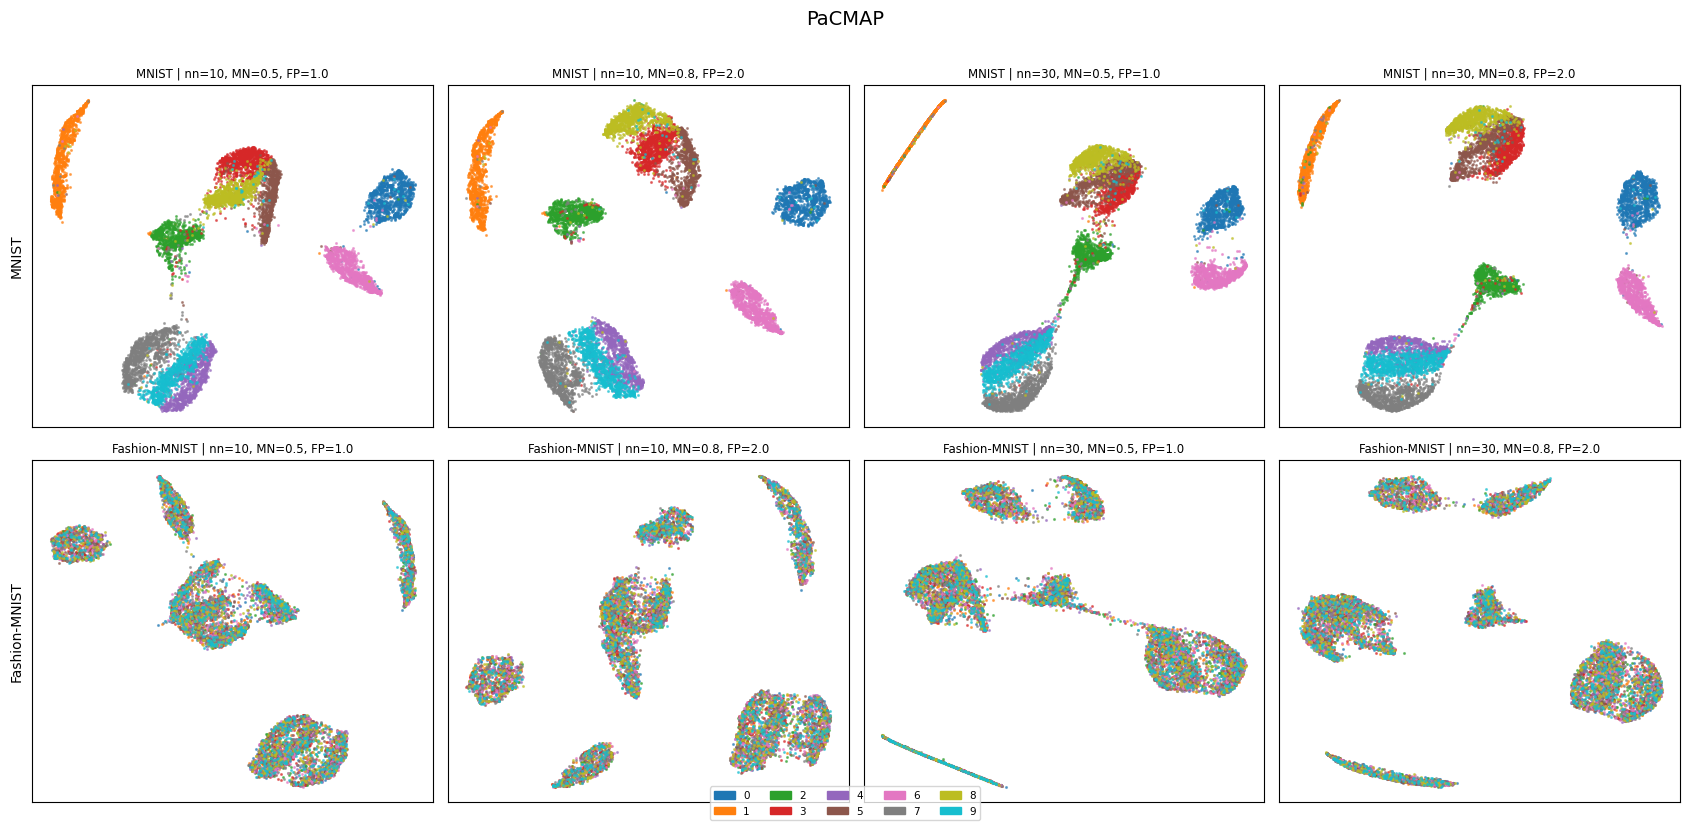

In [56]:
pacmap_configs = [
    {"n_neighbors": 10, "MN_ratio": 0.5, "FP_ratio": 1.0},
    {"n_neighbors": 10, "MN_ratio": 0.8, "FP_ratio": 2.0},
    {"n_neighbors": 30, "MN_ratio": 0.5, "FP_ratio": 1.0},
    {"n_neighbors": 30, "MN_ratio": 0.8, "FP_ratio": 2.0},
]
pacmap_emb = {}

for cfg in pacmap_configs:
    key = (cfg["n_neighbors"], cfg["MN_ratio"], cfg["FP_ratio"])
    reducer = pacmap.PaCMAP(n_components=2, random_state=42, **cfg)
    pacmap_emb[("mnist", *key)] = reducer.fit_transform(Xm_pca)
    pacmap_emb[("fashion", *key)] = reducer.fit_transform(Xf_pca)
    print(
        f"PaCMAP nn={cfg['n_neighbors']}, MN={cfg['MN_ratio']}, FP={cfg['FP_ratio']}  done"
    )

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for j, cfg in enumerate(pacmap_configs):
    key = (cfg["n_neighbors"], cfg["MN_ratio"], cfg["FP_ratio"])
    label = f"nn={key[0]}, MN={key[1]}, FP={key[2]}"
    scatter_emb(axes[0, j], pacmap_emb[("mnist", *key)], ym, f"MNIST | {label}")
    scatter_emb(
        axes[1, j], pacmap_emb[("fashion", *key)], yf, f"Fashion-MNIST | {label}"
    )

axes[0, 0].set_ylabel("MNIST", fontsize=10, labelpad=6)
axes[1, 0].set_ylabel("Fashion-MNIST", fontsize=10, labelpad=6)
fig.suptitle("PaCMAP", fontsize=14, y=1.01)
add_legend(fig, mnist_classes)
plt.tight_layout()
plt.show()

## Quantitative Evaluation

Metrics computed for every method × parameter setting × dataset:
- **NNCF** (Nearest Neighbor Class Fidelity, k_max=100) — jak dobrze punkty tej samej klasy pozostają blisko siebie w embeddingu
- **Trustworthiness** (k=10) — ile spośród k sąsiadów w embeddingu było też sąsiadami w oryginalnej przestrzeni

In [58]:
from sklearn.manifold import trustworthiness as sklearn_tw


class NearestNeighborClassFidelity:
    def __init__(self, X_low: np.ndarray, y: np.array, k_max: int = 100):
        self.X_low = X_low
        self.y = y
        self.k_max = k_max
        self.knn_low = NearestNeighbors().fit(X_low)

    def fidelity_k(self, k: int) -> float:
        n = len(self.y)
        _, neighbor_indices = self.knn_low.kneighbors(self.X_low, n_neighbors=k + 1)
        neighbor_indices = neighbor_indices[:, 1:]
        neighbor_classes = self.y[neighbor_indices]
        own_classes = self.y.reshape(-1, 1)
        hits = np.sum(neighbor_classes == own_classes, axis=1)
        return hits.sum() / (k * n)

    def compute(self) -> float:
        fidelity_scores = [self.fidelity_k(k) for k in range(1, self.k_max + 1)]
        return float(np.mean(fidelity_scores))

In [59]:
K_MAX = 100

all_configs = []

for perp in [5, 30, 50]:
    all_configs.append(
        ("t-SNE", f"perp={perp}", ("mnist", perp), ("fashion", perp), tsne_emb)
    )

for cfg in umap_configs:
    k = (cfg["n_neighbors"], cfg["min_dist"])
    all_configs.append(
        ("UMAP", f"nn={k[0]}, d={k[1]}", ("mnist", *k), ("fashion", *k), umap_emb)
    )

for cfg in trimap_configs:
    k = (cfg["n_inliers"], cfg["n_outliers"])
    all_configs.append(
        ("TriMAP", f"in={k[0]}, out={k[1]}", ("mnist", *k), ("fashion", *k), trimap_emb)
    )

for cfg in pacmap_configs:
    k = (cfg["n_neighbors"], cfg["MN_ratio"], cfg["FP_ratio"])
    all_configs.append(
        (
            "PaCMAP",
            f"nn={k[0]}, MN={k[1]}, FP={k[2]}",
            ("mnist", *k),
            ("fashion", *k),
            pacmap_emb,
        )
    )

records = []
fidelity_curves = {}

for method, cfg_label, key_m, key_f, emb_dict in all_configs:
    for dataset, key, X_high, labels in [
        ("MNIST", key_m, Xm_pca, ym),
        ("Fashion-MNIST", key_f, Xf_pca, yf),
    ]:
        emb = emb_dict[key]
        nncf_obj = NearestNeighborClassFidelity(emb, labels, k_max=K_MAX)
        fid_curve = [nncf_obj.fidelity_k(k) for k in range(1, K_MAX + 1)]
        nncf = float(np.mean(fid_curve))
        tw = sklearn_tw(X_high, emb, n_neighbors=10)

        records.append(
            {
                "Method": method,
                "Config": cfg_label,
                "Dataset": dataset,
                "NNCF": round(nncf, 4),
                "Trustworthiness": round(tw, 4),
            }
        )
        fidelity_curves[(method, cfg_label, dataset)] = fid_curve
        print(
            f"  {method:<8} {cfg_label:<28} {dataset:<15}  NNCF={nncf:.4f}  TW={tw:.4f}"
        )

df_metrics = pd.DataFrame(records)
print("\nDone.")

  t-SNE    perp=5                       MNIST            NNCF=0.8953  TW=0.9870
  t-SNE    perp=5                       Fashion-MNIST    NNCF=0.6897  TW=0.9942
  t-SNE    perp=30                      MNIST            NNCF=0.9073  TW=0.9898
  t-SNE    perp=30                      Fashion-MNIST    NNCF=0.7052  TW=0.9957
  t-SNE    perp=50                      MNIST            NNCF=0.9051  TW=0.9890
  t-SNE    perp=50                      Fashion-MNIST    NNCF=0.7008  TW=0.9951
  UMAP     nn=5, d=0.1                  MNIST            NNCF=0.8985  TW=0.9708
  UMAP     nn=5, d=0.1                  Fashion-MNIST    NNCF=0.6849  TW=0.9897
  UMAP     nn=15, d=0.5                 MNIST            NNCF=0.8707  TW=0.9497
  UMAP     nn=15, d=0.5                 Fashion-MNIST    NNCF=0.6511  TW=0.9777
  UMAP     nn=30, d=0.8                 MNIST            NNCF=0.8013  TW=0.9312


KeyboardInterrupt: 

In [ ]:
from IPython.display import display

for ds in ["MNIST", "Fashion-MNIST"]:
    sub = (
        df_metrics[df_metrics["Dataset"] == ds]
        .drop(columns="Dataset")
        .sort_values("NNCF", ascending=False)
        .reset_index(drop=True)
    )
    sub.index += 1
    print(f"\n{'─' * 55}")
    print(f"  {ds}")
    print(f"{'─' * 55}")
    display(
        sub.style.format(
            {"NNCF": "{:.4f}", "Trustworthiness": "{:.4f}"}
        ).background_gradient(subset=["NNCF", "Trustworthiness"], cmap="RdYlGn")
    )

### NNCF & Trustworthiness - Bar Charts

NameError: name 'df_metrics' is not defined

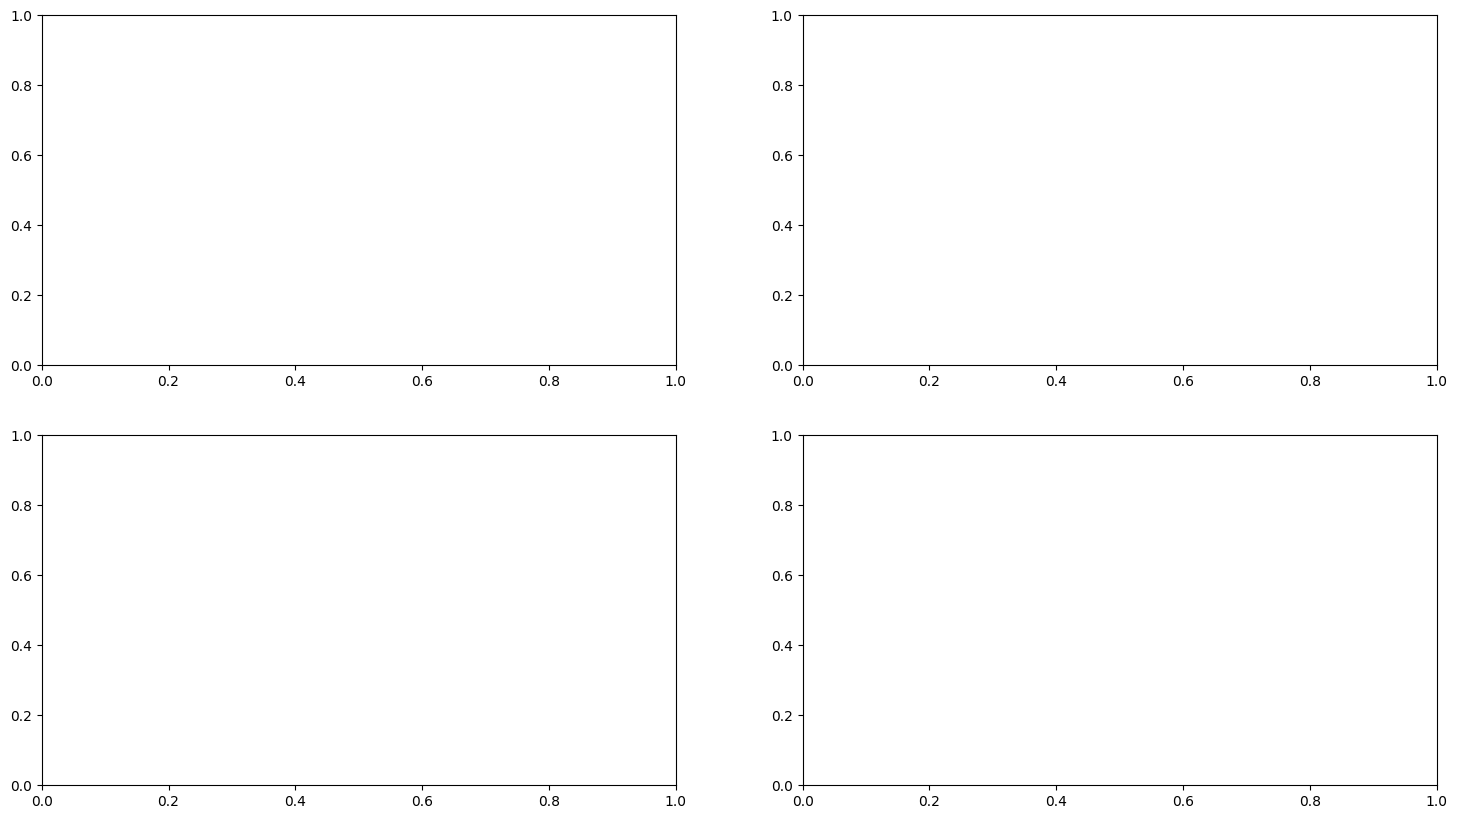

In [ ]:
METHOD_COLORS = {
    "t-SNE": "#4C72B0",
    "UMAP": "#DD8452",
    "TriMAP": "#55A868",
    "PaCMAP": "#C44E52",
}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for row, ds in enumerate(["MNIST", "Fashion-MNIST"]):
    sub = df_metrics[df_metrics["Dataset"] == ds].copy()
    sub["label"] = sub["Config"]
    colors = [METHOD_COLORS[m] for m in sub["Method"]]

    for col, metric in enumerate(["NNCF", "Trustworthiness"]):
        ax = axes[row, col]
        bars = ax.bar(
            range(len(sub)), sub[metric], color=colors, edgecolor="white", width=0.75
        )
        ax.set_xticks(range(len(sub)))
        ax.set_xticklabels(sub["label"], rotation=45, ha="right", fontsize=7.5)
        ax.set_title(f"{ds} — {metric}", fontsize=11)
        ax.set_ylim(0, 1.05)
        ax.axhline(
            0.1, color="gray", linestyle="--", linewidth=0.8, label="random baseline"
        )
        ax.grid(axis="y", alpha=0.3)
        # value labels on top of bars
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.01,
                f"{h:.3f}",
                ha="center",
                va="bottom",
                fontsize=6.5,
            )

    # method legend
    handles = [mpl.patches.Patch(color=c, label=m) for m, c in METHOD_COLORS.items()]
    axes[row, 0].legend(handles=handles, fontsize=8, loc="lower right")

plt.suptitle("NNCF and Trustworthiness by Method & Config", fontsize=14)
plt.tight_layout()
plt.show()

### Fidelity@k Curves

In [ ]:
k_range = list(range(1, K_MAX + 1))
methods = ["t-SNE", "UMAP", "TriMAP", "PaCMAP"]
datasets = ["MNIST", "Fashion-MNIST"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)

for col, method in enumerate(methods):
    # all configs that belong to this method
    cfg_labels = [c for m, c, _ in fidelity_curves.keys() if m == method]
    cfg_labels = list(dict.fromkeys(cfg_labels))  # deduplicate, preserve order
    cmap_fn = plt.get_cmap("tab10")

    for row, ds in enumerate(datasets):
        ax = axes[row, col]
        for i, cfg in enumerate(cfg_labels):
            curve = fidelity_curves[(method, cfg, ds)]
            ax.plot(
                k_range, curve, label=cfg, linewidth=1.4, color=cmap_fn(i), alpha=0.85
            )
        ax.axhline(0.1, color="gray", linestyle=":", linewidth=0.8)
        ax.set_title(f"{method}\n{ds}", fontsize=9)
        ax.set_xlabel("k", fontsize=8)
        if col == 0:
            ax.set_ylabel("fidelity_k", fontsize=8)
        ax.legend(fontsize=6, loc="upper right")
        ax.grid(alpha=0.25)

plt.suptitle("NNCF: fidelity@k curves (dashed = random baseline 0.1)", fontsize=13)
plt.tight_layout()
plt.show()